# 📊 Urban Mobility and Economic Indicators Analysis (2024)

## 📝 Project Description
This project analyzes the relationship between urban traffic patterns and socioeconomic indicators across various global cities during 2024. The main objective is to consolidate and clean data from different sources to explore how traffic congestion metrics (delays, jams, travel times) interact with economic and demographic factors (GDP per capita, unemployment, air quality, and population).

---

## 🎯 Main Objectives
1. **Data Cleaning and Preparation:** Standardize variable names, fix date formats, and perform numeric type casting.
2. **Temporal Filtering:** Restrict the analysis to the most recent and relevant period (**year 2024**).
3. **City Aggregation:** Consolidate mobility metrics by calculating annual averages per city/country.
4. **Dataset Integration:** Merge traffic data with OECD economic indicators using an *Inner Join*.

---

## 📁 Data Sources
* `tomtom_traffic.csv`: Live and historical traffic records by city (traffic index, delay in minutes, jam length, etc.).
* `oecd_city_economy.csv`: City-level economic and demographic indicators (GDP per capita, unemployment rate, PM2.5 levels, and population).

---


In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [4]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') 

In [5]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [6]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


### 2.1 Explore Data Structure and Types

**🎯 Objective:**
Identify columns with incorrect data types, distributions, and null values, and note the columns requiring conversion.


In [7]:
# Examinar la estructura de traffic
traffic.info(); display(traffic.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


Looking at the structure of the `traffic` DataFrame, we can observe that:
- The `UpdateTimeUTC` and `UpdateTimeUTCWeekAgo` columns are not of type `datetime64`. Both need to be converted to enable filtering by day of the week, hour, etc.
- `JamsCount` should be converted to `int64`, as decimal values are unnecessary when counting traffic jams.
- `Country` and `City` would work better as `category` types for a cleaner and more efficient analysis.

In [8]:
# Examinar la estructura de eco
eco.info(); display(eco.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, PM2.5 hay que convertirlas a float64. Year convendría convertirla a DateTime64.

In [9]:
# 1. Renombrar columnas de traffic a snake_case
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [10]:
# 2. Renombrar columnas de eco a snake_case

eco.columns = ['year', 'city', 'country', 'city_gdp_per_capita', 'unemployment_pct', 'pm25', 'population_m']

print(eco[['city_gdp_per_capita', 'unemployment_pct', 'pm25', 'population_m']].dtypes)

city_gdp_per_capita    object
unemployment_pct       object
pm25                   object
population_m           object
dtype: object


In [11]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])
# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [12]:

# Limpiar GDP
eco['city_gdp_per_capita'] = (
    eco['city_gdp_per_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Limpiar Porcentaje de Desempleo
eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Limpiar PM2.5
eco['pm25'] = (
    eco['pm25']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Limpiar Población
eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Crear población absoluta
eco['population'] = eco['population_m'] * 1_000_000

# Convertir población a entero
eco['population'] = eco['population'].astype(int)

# Verificar
eco.info()
print(eco.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   city_gdp_per_capita  30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25                 30 non-null     float64
 6   population_m         30 non-null     float64
 7   population           30 non-null     int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 2.0+ KB
   year            city    country  city_gdp_per_capita  unemployment_pct  \
0  2023    buenos-aires  Argentina              15782.0               6.2   
1  2023       sao-paulo     Brazil              14475.0               9.1   
2  2023  rio-de-janeiro     Brazil              13142.0               9.8   

   pm25  population_m  popu

In [13]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [15]:
# Extraer año 2024 de ambos dataframes y crear la respectiva copia
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000


In [16]:

# Agrupar y calcular promedios de las métricas de tráfico relevantes
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year']).agg({
    'jams_delay': 'mean',
    'traffic_index_live': 'mean',
    'jams_length_in_kms': 'mean',
    'jams_count': 'mean',
    'mins_delay': 'mean',
    'travel_time_live_per_10kms_mins': 'mean',
    'travel_time_historic_per_10kms_mins': 'mean'
}).reset_index()

# Verificar el DataFrame resultante
display(traffic_city_year_2024.head())

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [23]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


In [17]:

# Seleccionar columnas clave de tráfico y economía
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
             'jams_length_in_kms', 'jams_count', 'mins_delay',
             'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']

right_cols = ['city', 'year', 'city_gdp_per_capita', 'unemployment_pct', 'pm25', 'population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets (Inner join para mantener solo coincidencia de ciudad y año)
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'year'],
    how='inner'
)

# Mostrar las primeras 5 filas
display(merged.head(5))


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000


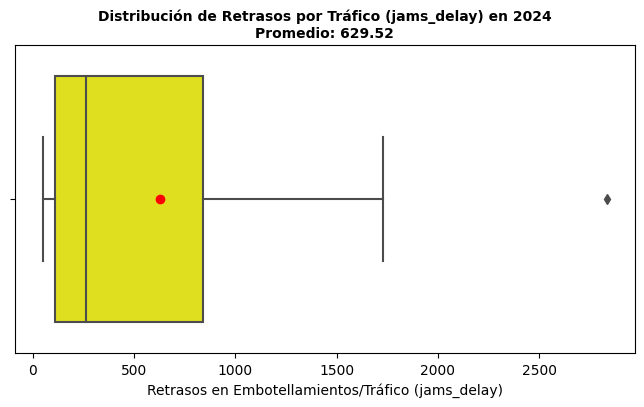

In [26]:

# 1. Calcular el promedio primero
mean_value = merged['jams_delay'].mean()

# 2. Crear la figura
plt.figure(figsize=(8, 4))
sns.boxplot(
    x=merged['jams_delay'], 
    color='yellow', 
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"}
)

# 3. Configurar título (incluyendo el promedio) y etiquetas
plt.title(f'Distribución de Retrasos por Tráfico (jams_delay) en 2024\nPromedio: {mean_value:.2f}', fontsize=10, fontweight='bold')
plt.xlabel('Retrasos en Embotellamientos/Tráfico (jams_delay)', fontsize=10)

# 4. Mostrar el gráfico una sola vez
plt.show()


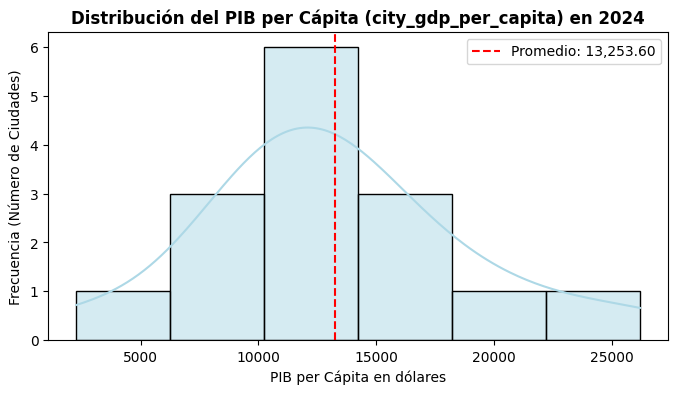

In [30]:
# 2. Histograma para city_gdp_per_capita (Economía)
plt.figure(figsize=(8, 4))
sns.histplot(merged['city_gdp_per_capita'], kde=True, color='lightblue', bins)

# Línea vertical para señalar el valor promedio
gdp_mean = merged['city_gdp_per_capita'].mean()
plt.axvline(gdp_mean, color='red', linestyle='--', label=f'Promedio: {gdp_mean:,.2f}')

plt.title('Distribución del PIB per Cápita (city_gdp_per_capita) en 2024', fontsize=12, fontweight='bold')
plt.xlabel('PIB per Cápita en dólares', fontsize=10)
plt.ylabel('Frecuencia (Número de Ciudades)', fontsize=10)
plt.legend()
plt.show()

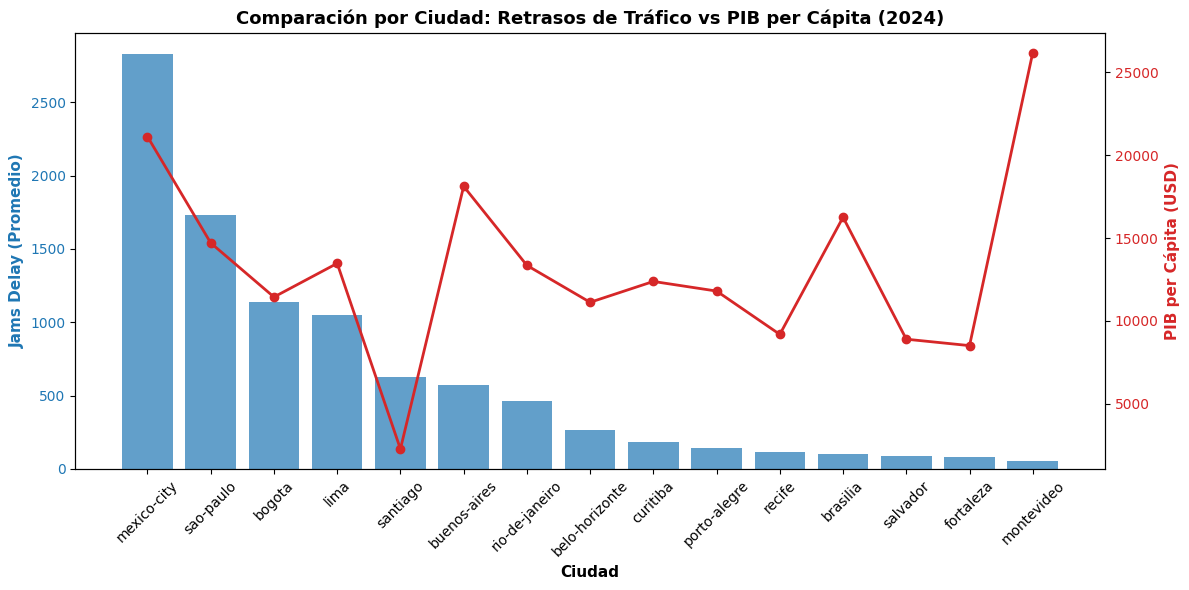

In [20]:
# 3. Gráfico de Barras Comparativo (Tráfico vs PIB por Ciudad)
# Ordenar por retraso de tráfico para facilitar la comparación
merged_sorted = merged.sort_values(by='jams_delay', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barra principal: jams_delay (Eje Izquierdo)
color_bar = 'tab:blue'
ax1.set_xlabel('Ciudad', fontsize=11, fontweight='bold')
ax1.set_ylabel('Jams Delay (Promedio)', color=color_bar, fontsize=11, fontweight='bold')
bars = ax1.bar(merged_sorted['city'], merged_sorted['jams_delay'], color=color_bar, alpha=0.7, label='Jams Delay')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.tick_params(axis='x', rotation=45)

# Eje secundario para el PIB per Cápita (Eje Derecho)
ax2 = ax1.twinx()
color_line = 'tab:red'
ax2.set_ylabel('PIB per Cápita (USD)', color=color_line, fontsize=11, fontweight='bold')
lines = ax2.plot(merged_sorted['city'], merged_sorted['city_gdp_per_capita'], color=color_line, marker='o', linewidth=2, label='PIB per Cápita')
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title('Comparación por Ciudad: Retrasos de Tráfico vs PIB per Cápita (2024)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [22]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# 🧾 Executive Summary

**Context & Objective:**  
The objective of this analysis is to evaluate the relationship between urban mobility (traffic congestion, delays, and travel times) and economic productivity (GDP per capita) at the metropolitan level.  
Key variables:
- `jams_delay` and `traffic_index_live`: Indicate congestion severity and time lost in traffic jams.
- `travel_time_live_per_10kms_mins`: Minutes required to travel 10 km.
- `city_gdp_per_capita`: Reflects economic output per inhabitant.  
Decision-making relevance: These serve as core urban mobility indicators. High traffic congestion combined with low economic productivity signals reduced economic competitiveness.

**Data Coverage:**  
- Analyzed Year: 2024 (filtered and standardized using `.copy()`).
- Geographic Scope: Thirty (30) cities across various countries.

**Methodology (High-Level):**  
1. **Cleaning and Standardization:**
   - Standardized column names to `snake_case`.
   - Converted temporal variables using `.dt.year` while keeping `year` as `int64` to preserve compatibility across table joins.
   - Cleaned text characters in numeric variables (`population_m`, `city_gdp_per_capita`, `pm25`).
2. **Aggregations & Dataset Joining:**
   - Calculated annual averages (`.mean()`) for key traffic metrics grouped by `city`, `country`, and `year`.
   - Joined datasets using `pd.merge(..., how='inner', on=['city', 'year'])`, ensuring only cities with complete coverage across both dimensions were retained in the new `merged` table.
3. **Visual Validation:**
   - **Boxplot (`jams_delay`):** Identified mean, median, and outliers.
   - **Histogram (`city_gdp_per_capita`):** Evaluated wealth distribution across urban areas.
   - **Combined Bar/Line Chart:** Contrasted lost time against GDP per capita by city.

**Initial Findings:**  
- A higher GDP per capita does not necessarily imply greater traffic congestion, as higher-income cities often offset vehicle density through efficient public transit infrastructure.
- Developing cities show the highest delay levels relative to GDP, pointing to significant deficits in public transit infrastructure.

**Recommendations:**  
- **Priority Cities:** Bogotá and Lima stand out as urgent targets for intervention. Both exhibit a critical pattern: traffic delay metrics (`jams_delay` and travel time per 10 km) rank among the highest in the regional sample, while `city_gdp_per_capita` remains at mid-to-low levels.
- **Buenos Aires:** Experiences considerable peak-hour congestion, but its economy is not as severely constrained by it.
- **Bogotá:** Displays the widest gap between time lost in transit and per capita economic productivity, placing it as the top priority for public transit and road infrastructure investment.
- **Priority Investment:** Allocate development funds toward public transit in high-congestion/low-GDP cities (such as Bogotá and Lima) to unlock per capita productivity growth.


